# 03 · Scenario comparison

Compares the three grid-service scenarios over the sample week. It reuses the
cached `df_summary_*.joblib` from notebook 02; if they are missing it recomputes
them, so this notebook is independently runnable.

| Scenario | Service | Colour |
|---|---|---|
| BASELINE | energy shifting | blue `#0571B0` |
| DAM (*Intraday*) | day-ahead / intraday | red `#FC9272` |
| mFRR | manual frequency restoration reserve | green `#A6D854` |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from lad_flex import *

sns.set_theme(style="whitegrid")
os.makedirs("outputs", exist_ok=True)
SCENARIOS = ["BASELINE", "DAM", "mFRR"]

missing = [s for s in SCENARIOS if not os.path.exists(f"outputs/df_summary_{s}.joblib")]
if missing:
    print("Recomputing missing scenarios:", missing)
    df = pd.read_csv("data/df_tasks_sample.csv", parse_dates=["start_time", "end_time"]).set_index("task_name")
    dpe = fast_power_energy_series(df, get_timeline(df))
    sw = pd.date_range("1970-02-01", "1970-02-08", freq="h")
    for s in missing:
        p = return_params("DEFAULT", s)
        mr = (max(p["delta_notifications"]) + max(p["flex_windows"]) + max(p["gamma_buffers"])).total_seconds()
        ds, _ = run_lad_flex_sweep(df[df["runtime_i"] <= mr], dpe, sw, p)
        joblib.dump(ds, f"outputs/df_summary_{s}.joblib")

summaries = {s: joblib.load(f"outputs/df_summary_{s}.joblib") for s in SCENARIOS}
print("loaded:", list(summaries))

loaded: ['BASELINE', 'DAM', 'mFRR']


## Distribution of deferrable energy and flexible share

C:\Users\citcea\AppData\Local\Temp\ipykernel_20156\3197095991.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data, labels=[SCENARIO_DISPLAY[s] for s in SCENARIOS], patch_artist=True)
C:\Users\citcea\AppData\Local\Temp\ipykernel_20156\3197095991.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(data2, labels=[SCENARIO_DISPLAY[s] for s in SCENARIOS], patch_artist=True)


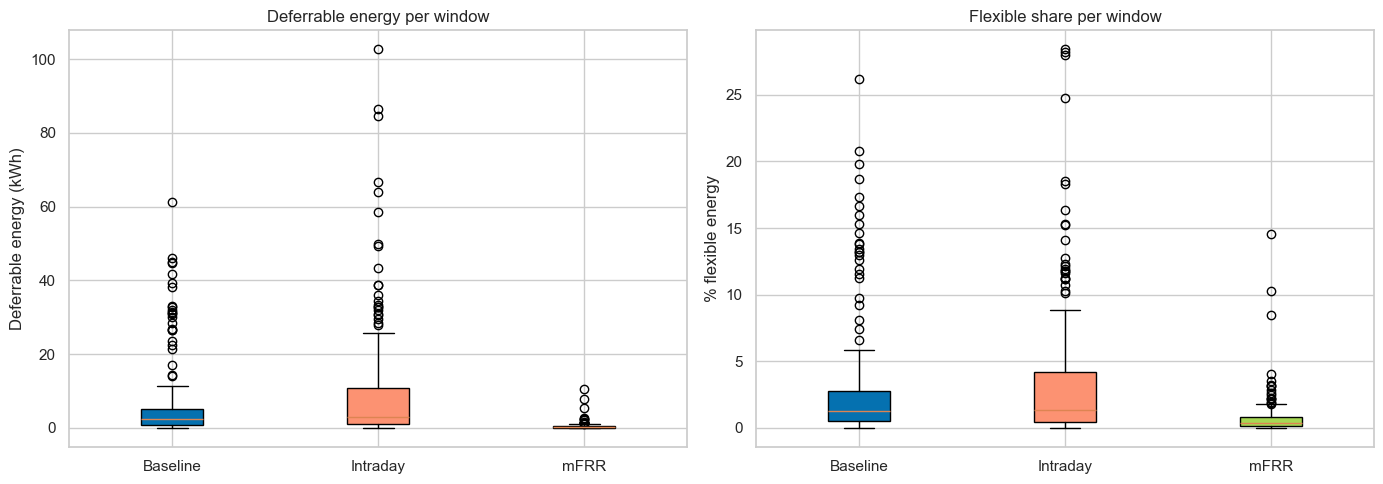

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
data = [deferrable_energy_timeseries(summaries[s]).values for s in SCENARIOS]
bp = axes[0].boxplot(data, labels=[SCENARIO_DISPLAY[s] for s in SCENARIOS], patch_artist=True)
for patch, s in zip(bp["boxes"], SCENARIOS):
    patch.set_facecolor(SCENARIO_COLORS[s])
axes[0].set_ylabel("Deferrable energy (kWh)"); axes[0].set_title("Deferrable energy per window")

data2 = [summaries[s]["percentage_flexible_energy"].values for s in SCENARIOS]
bp2 = axes[1].boxplot(data2, labels=[SCENARIO_DISPLAY[s] for s in SCENARIOS], patch_artist=True)
for patch, s in zip(bp2["boxes"], SCENARIOS):
    patch.set_facecolor(SCENARIO_COLORS[s])
axes[1].set_ylabel("% flexible energy"); axes[1].set_title("Flexible share per window")
plt.tight_layout(); plt.savefig("outputs/cmp_boxplots.png", dpi=150); plt.show()

## Deferrable energy over the sample week

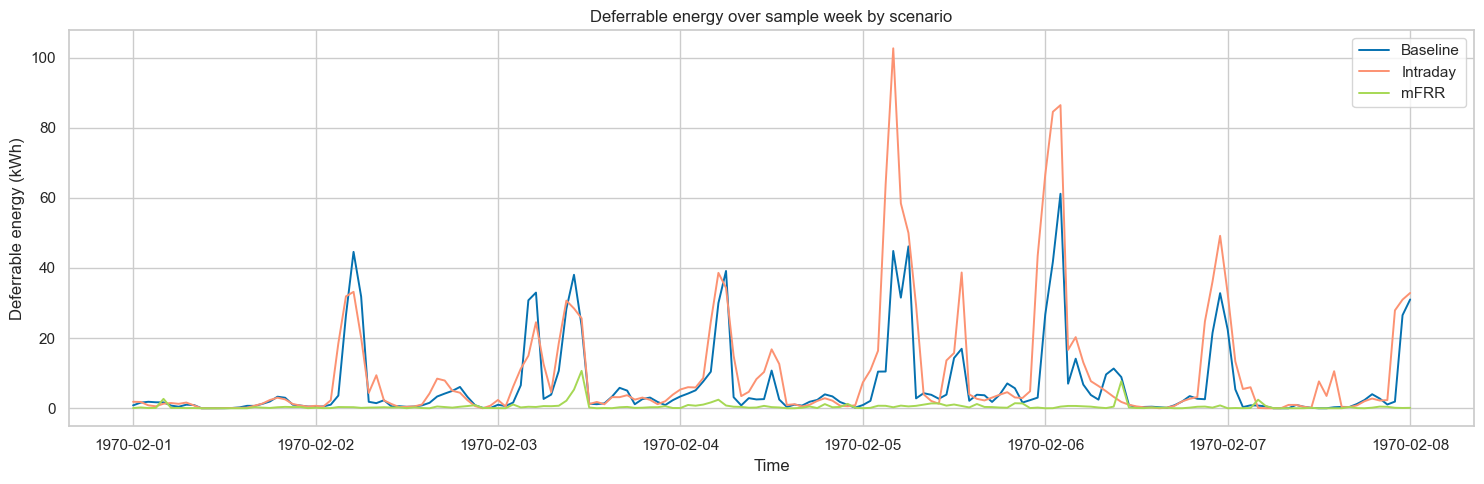

In [3]:
fig, ax = plt.subplots(figsize=(15, 5))
for s in SCENARIOS:
    ser = deferrable_energy_timeseries(summaries[s])
    ax.plot(ser.index, ser.values, color=SCENARIO_COLORS[s], lw=1.4, label=SCENARIO_DISPLAY[s])
ax.set_xlabel("Time"); ax.set_ylabel("Deferrable energy (kWh)")
ax.set_title("Deferrable energy over sample week by scenario"); ax.legend()
plt.tight_layout(); plt.savefig("outputs/cmp_timeseries.png", dpi=150); plt.show()

## Hourly flexibility efficiency (kWh per flex-window hour)

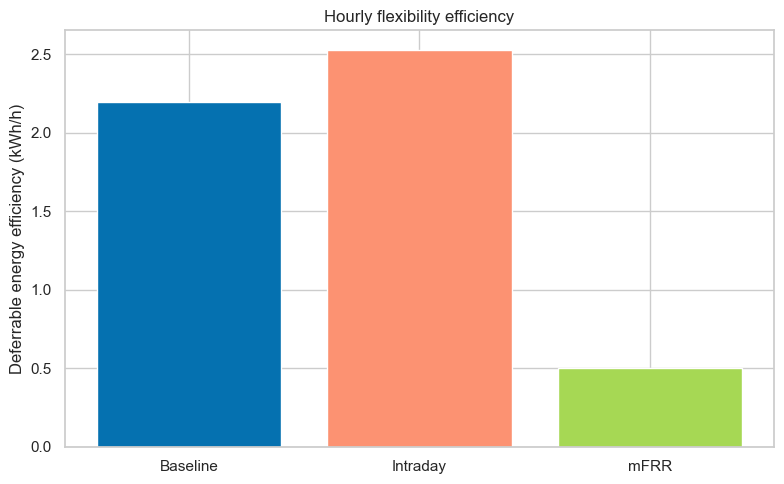

,scenario,mean_deferrable_kWh,flex_window_h,efficiency_kWh_per_h,mean_pct_flexible
0,Baseline,6.59,3.0,2.20,3.18
1,Intraday,10.10,4.0,2.53,3.65
2,mFRR,0.50,1.0,0.50,0.79


In [4]:
rows = []
for s in SCENARIOS:
    p = return_params("DEFAULT", s)
    fwh = p["flex_windows"][0].total_seconds() / 3600
    ser = deferrable_energy_timeseries(summaries[s])
    rows.append({
        "scenario": SCENARIO_DISPLAY[s],
        "mean_deferrable_kWh": ser.mean(),
        "flex_window_h": fwh,
        "efficiency_kWh_per_h": ser.mean() / fwh,
        "mean_pct_flexible": summaries[s]["percentage_flexible_energy"].mean(),
    })
eff = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(eff["scenario"], eff["efficiency_kWh_per_h"],
       color=[SCENARIO_COLORS[s] for s in SCENARIOS])
ax.set_ylabel("Deferrable energy efficiency (kWh/h)")
ax.set_title("Hourly flexibility efficiency")
plt.tight_layout(); plt.savefig("outputs/cmp_efficiency.png", dpi=150); plt.show()
eff.round(2)

## Summary table

In [5]:
summary_tbl = eff.round(2)
summary_tbl.to_csv("outputs/scenario_comparison_summary.csv", index=False)
summary_tbl

,scenario,mean_deferrable_kWh,flex_window_h,efficiency_kWh_per_h,mean_pct_flexible
0,Baseline,6.59,3.0,2.20,3.18
1,Intraday,10.10,4.0,2.53,3.65
2,mFRR,0.50,1.0,0.50,0.79


## Beyond energy: the *value* of flexibility

So far we measured deferrable **energy**. But grid services pay differently
depending on the **notification period** δ (`Value(δ)` in `lad_flex.py`): faster
products pay more per kWh. We need the raw sample to run the value sweeps below.

In [6]:
try:
    df
except NameError:
    df = pd.read_csv("data/df_tasks_sample.csv", parse_dates=["start_time", "end_time"]).set_index("task_name")
try:
    df_power_energy
except NameError:
    df_power_energy = fast_power_energy_series(df, get_timeline(df))
sw = pd.date_range("1970-02-01", "1970-02-08", freq="h")
print("ready: tasks =", len(df))

ready: tasks = 100000


### Weekly flexibility revenue per scenario

`revenue = Σ deferrable_kWh × Value(δ)`. Note the **inversion**: mFRR pays the most per kWh but defers the least energy.

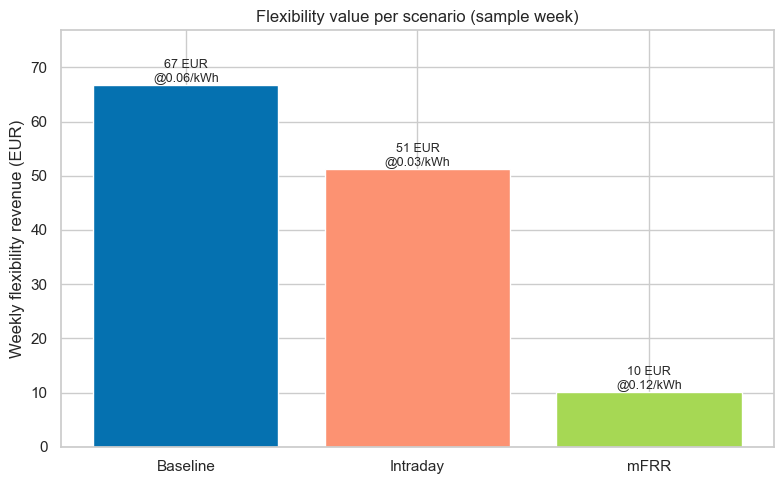

,scenario,delta_min,value_eur_per_kWh,week_deferrable_kWh,week_revenue_eur
0,Baseline,60,0.06,1114.0,66.8
1,Intraday,180,0.03,1708.0,51.2
2,mFRR,15,0.12,85.0,10.2


In [7]:
rev = []
for s in SCENARIOS:
    p = return_params("DEFAULT", s)
    delta = p["delta_notifications"][0]
    v = Value(delta)
    tot = deferrable_energy_timeseries(summaries[s]).sum()
    rev.append({"scenario": SCENARIO_DISPLAY[s], "delta_min": int(delta.total_seconds() / 60),
                "value_eur_per_kWh": v, "week_deferrable_kWh": round(tot, 0),
                "week_revenue_eur": round(tot * v, 1)})
revdf = pd.DataFrame(rev)
revdf.to_csv("outputs/scenario_revenue.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(revdf["scenario"], revdf["week_revenue_eur"], color=[SCENARIO_COLORS[s] for s in SCENARIOS])
for i, r in revdf.iterrows():
    ax.text(i, r["week_revenue_eur"], f"{r['week_revenue_eur']:.0f} EUR\n@{r['value_eur_per_kWh']}/kWh",
            ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Weekly flexibility revenue (EUR)")
ax.set_title("Flexibility value per scenario (sample week)")
ax.margins(y=0.15)
plt.tight_layout(); plt.savefig("outputs/cmp_revenue.png", dpi=150); plt.show()
revdf

### Optimal notification period δ\*

Sweep δ for BASELINE parameters. Longer notification lets **more** tasks qualify
(F rises), but each kWh is worth **less** (V falls). Revenue `R = F·V` trades these
off and is maximized at δ\*.

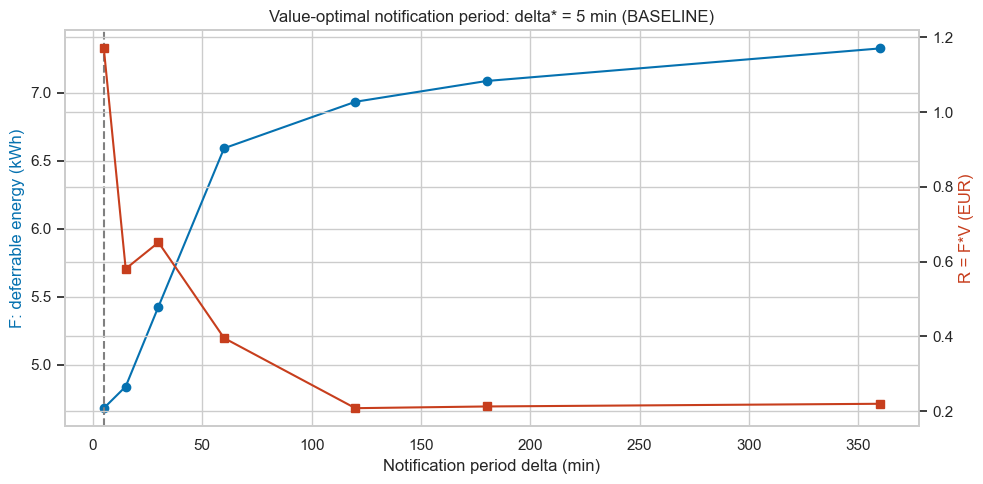

,delta_min,F_kWh,V_eur_per_kWh,R_eur
0,5,4.681,0.25,1.170
1,15,4.840,0.12,0.581
2,30,5.428,0.12,0.651
3,60,6.592,0.06,0.396
4,120,6.934,0.03,0.208
5,180,7.087,0.03,0.213
6,360,7.327,0.03,0.220


In [8]:
p = return_params("DEFAULT", "BASELINE")
p_delta = dict(p)
deltas = [pd.Timedelta(minutes=m) for m in [5, 15, 30, 60, 120, 180, 360]]
p_delta["delta_notifications"] = deltas
mr = (max(deltas) + max(p["flex_windows"]) + max(p["gamma_buffers"])).total_seconds()

ds_delta, _ = run_lad_flex_sweep(df[df["runtime_i"] <= mr], df_power_energy, sw, p_delta)
g = ds_delta.groupby("delta_notification")["deferrable_energy_kWh"].mean()

opt = pd.DataFrame([{"delta_min": int(d.total_seconds() / 60), "F_kWh": F,
                     "V_eur_per_kWh": Value(d), "R_eur": F * Value(d)}
                    for d, F in g.items()]).sort_values("delta_min")
dstar = int(opt.loc[opt["R_eur"].idxmax(), "delta_min"])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(opt["delta_min"], opt["F_kWh"], "-o", color="#0571B0", label="F: deferrable energy (kWh)")
ax.set_xlabel("Notification period delta (min)"); ax.set_ylabel("F: deferrable energy (kWh)", color="#0571B0")
ax2 = ax.twinx()
ax2.plot(opt["delta_min"], opt["R_eur"], "-s", color="#C73E1D", label="R = F*V (EUR)")
ax2.set_ylabel("R = F*V (EUR)", color="#C73E1D")
ax.axvline(dstar, ls="--", color="gray")
ax.set_title(f"Value-optimal notification period: delta* = {dstar} min (BASELINE)")
plt.tight_layout(); plt.savefig("outputs/cmp_optimal_delta.png", dpi=150); plt.show()
opt.round(3)

### When is deferrable energy actually available?

Day-of-week × hour-of-day heatmaps of mean deferrable energy per scenario.

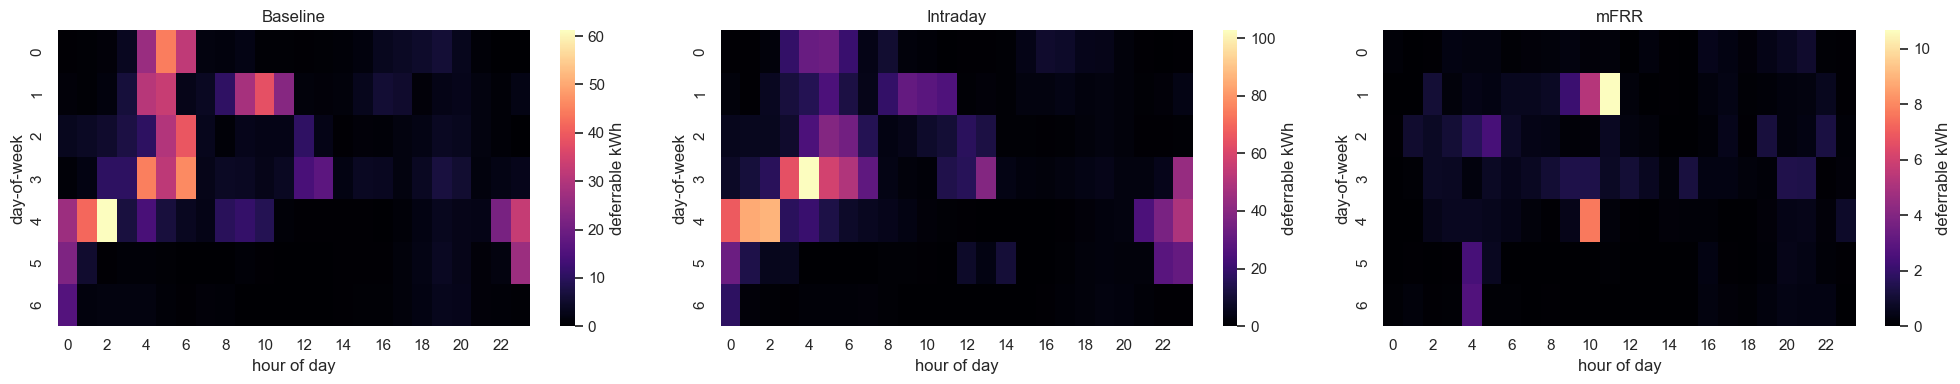

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4))
for ax, s in zip(axes, SCENARIOS):
    ser = deferrable_energy_timeseries(summaries[s]).to_frame("e")
    ser["dow"] = ser.index.dayofweek; ser["hour"] = ser.index.hour
    mat = ser.pivot_table(index="dow", columns="hour", values="e", aggfunc="mean")
    sns.heatmap(mat, cmap="magma", ax=ax, cbar_kws={"label": "deferrable kWh"})
    ax.set_title(SCENARIO_DISPLAY[s]); ax.set_xlabel("hour of day"); ax.set_ylabel("day-of-week")
plt.tight_layout(); plt.savefig("outputs/cmp_deferrable_heatmap.png", dpi=150); plt.show()

### How much latency tolerance is required?

Deferrable energy vs the latency threshold λ̂ (BASELINE). Demanding more latency tolerance shrinks the eligible pool.

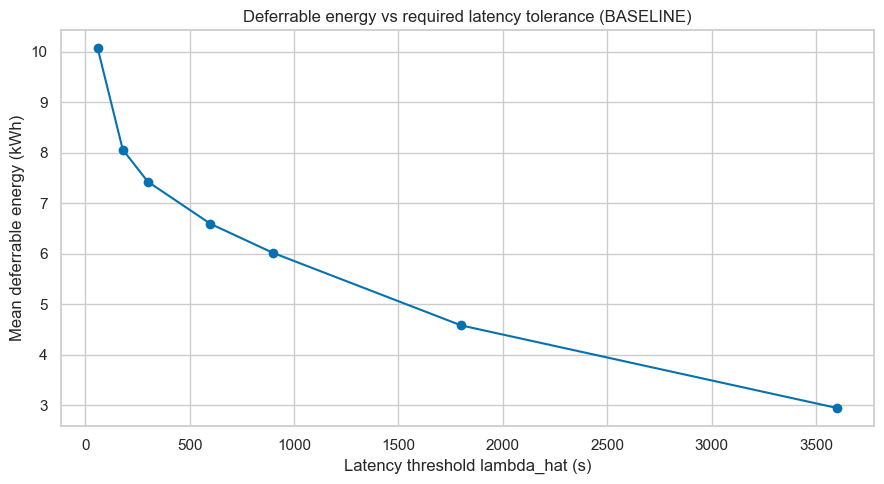

In [10]:
p = return_params("DEFAULT", "BASELINE")
p_lat = dict(p)
p_lat["latencies"] = [60, 180, 300, 600, 900, 1800, 3600]
mr = (max(p["delta_notifications"]) + max(p["flex_windows"]) + max(p["gamma_buffers"])).total_seconds()

ds_lat, _ = run_lad_flex_sweep(df[df["runtime_i"] <= mr], df_power_energy, sw, p_lat)
gl = ds_lat.groupby("latency")["deferrable_energy_kWh"].mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(gl.index, gl.values, "-o", color="#0571B0")
ax.set_xlabel("Latency threshold lambda_hat (s)"); ax.set_ylabel("Mean deferrable energy (kWh)")
ax.set_title("Deferrable energy vs required latency tolerance (BASELINE)")
plt.tight_layout(); plt.savefig("outputs/cmp_latency_curve.png", dpi=150); plt.show()

### Deferrable-energy duration curve (peak-shaving view)

Per-window deferrable energy sorted descending: flexibility is concentrated in a small fraction of windows.

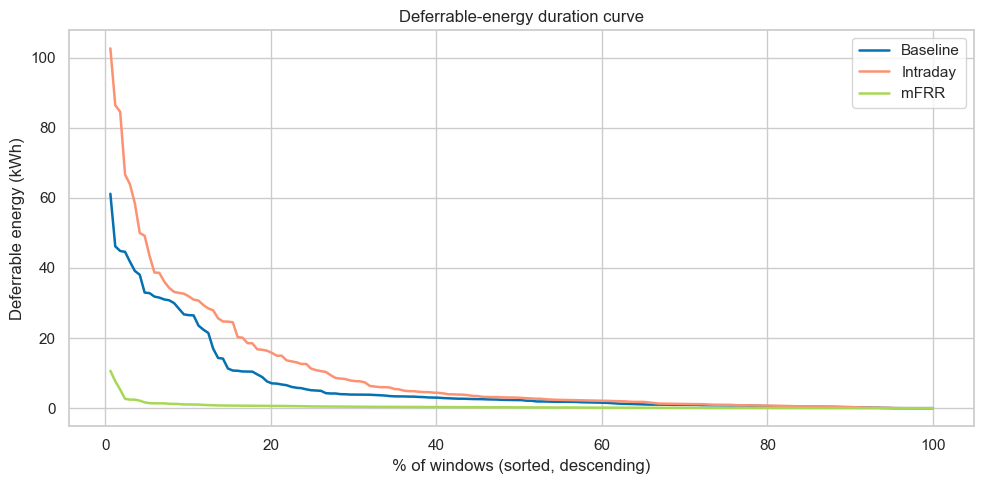

Baseline : top-10% windows mean   37.0 kWh vs overall   6.6 kWh
Intraday : top-10% windows mean   53.2 kWh vs overall  10.1 kWh
mFRR     : top-10% windows mean    2.8 kWh vs overall   0.5 kWh


In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
for s in SCENARIOS:
    ser = deferrable_energy_timeseries(summaries[s]).sort_values(ascending=False).values
    ax.plot(np.arange(1, len(ser) + 1) / len(ser) * 100, ser,
            color=SCENARIO_COLORS[s], lw=1.8, label=SCENARIO_DISPLAY[s])
ax.set_xlabel("% of windows (sorted, descending)"); ax.set_ylabel("Deferrable energy (kWh)")
ax.set_title("Deferrable-energy duration curve"); ax.legend()
plt.tight_layout(); plt.savefig("outputs/cmp_load_duration.png", dpi=150); plt.show()

for s in SCENARIOS:
    ser = deferrable_energy_timeseries(summaries[s])
    top10 = ser.sort_values(ascending=False).head(max(1, int(len(ser) * 0.1))).mean()
    print(f"{SCENARIO_DISPLAY[s]:9s}: top-10% windows mean {top10:6.1f} kWh vs overall {ser.mean():5.1f} kWh")

Next: **`04_uncertainty_sensitivity.ipynb`** — how robust are these decisions to duration-prediction error and parameter choices?